Файл 'monte-carlo-trial-data.csv' успешно загружен. Данных строк: 200


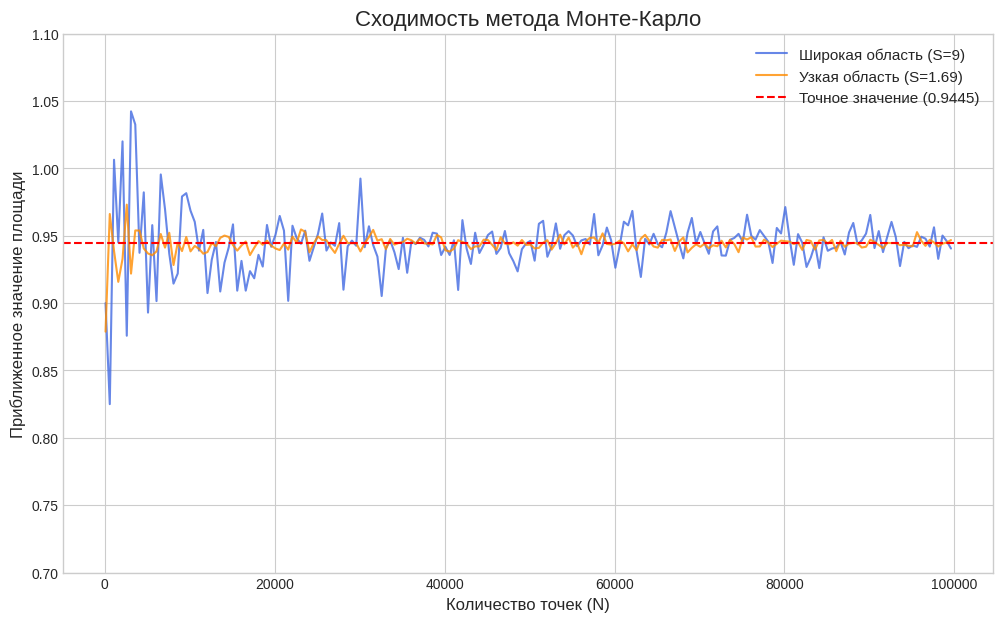

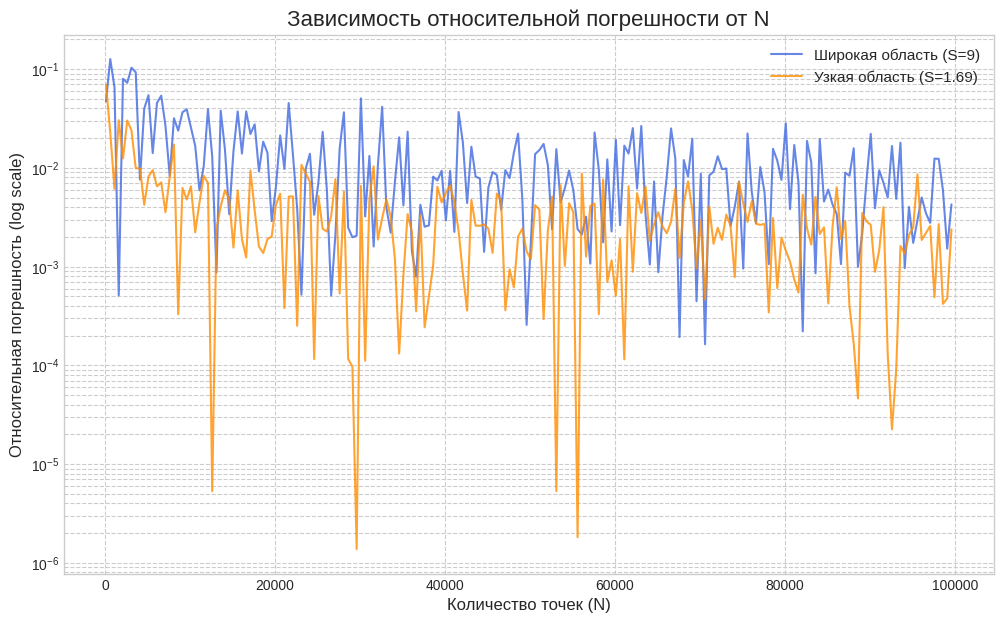

In [4]:
# =============================================================================
# === Раздел 1: Импорт необходимых библиотек ===
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# === Раздел 2: Конфигурация и загрузка данных из файла ===
# =============================================================================

# Если вы назовете файл по-другому, просто измените эту строку.
file_name = 'monte-carlo-trial-data.csv'

# Точное, аналитически вычисленное значение площади.
exact_area = 0.944517

try:
    df = pd.read_csv(file_name)
    print(f"Файл '{file_name}' успешно загружен. Данных строк: {len(df)}")
except FileNotFoundError:
    print(f"ОШИБКА: Файл '{file_name}' не найден!")
    # Присваиваем df значение None, чтобы код не пытался строить графики без данных.
    df = None

if df is not None:
    # =========================================================================
    # === Раздел 3: Построение графиков ===
    # =========================================================================
    plt.style.use('seaborn-v0_8-whitegrid')

    # --- График 1: Сходимость приближенного значения площади ---
    # plt.subplots() создает "холст" (fig) и "область для рисования" (ax).
    # figsize=(12, 7) задает размер картинки в дюймах, делая ее большой и четкой.
    fig1, ax1 = plt.subplots(figsize=(12, 7))

    # Рисуем линию для "широкой" области.
    # df['N'] - это данные для оси X (количество точек).
    # df['Wide_Area'] - данные для оси Y.
    # label - текст, который будет показан в легенде.
    # color и alpha - цвет и прозрачность линии.
    ax1.plot(df['N'], df['Wide_Area'], label='Широкая область (S=9)', color='royalblue', alpha=0.8)

    # Аналогично рисуем линию для "узкой" области.
    ax1.plot(df['N'], df['Narrow_Area'], label='Узкая область (S=1.69)', color='darkorange', alpha=0.8)

    # ax1.axhline() рисует горизонтальную линию на графике.
    # Она представляет наше эталонное "точное значение".
    # linestyle='--' делает ее пунктирной.
    ax1.axhline(y=exact_area, color='red', linestyle='--', label=f'Точное значение ({exact_area:.4f})')

    # Добавляем к графику заголовок и подписи осей.
    ax1.set_title('Сходимость метода Монте-Карло', fontsize=16)
    ax1.set_xlabel('Количество точек (N)', fontsize=12)
    ax1.set_ylabel('Приближенное значение площади', fontsize=12)

    # ax1.set_ylim() устанавливает пределы для оси Y. Это помогает "приблизить"
    # график к интересной нам области и лучше рассмотреть колебания.
    ax1.set_ylim(0.7, 1.1)

    # ax1.legend() - важнейшая команда. Она собирает все 'label',
    # которые мы задали при рисовании линий, и отображает их в виде легенды.
    ax1.legend(fontsize=11)

    # --- График 2: Зависимость относительной погрешности от N ---
    fig2, ax2 = plt.subplots(figsize=(12, 7))

    # Рисуем графики погрешностей для обеих областей.
    ax2.plot(df['N'], df['Wide_Rel_Error'], label='Широкая область (S=9)', color='royalblue', alpha=0.8)
    ax2.plot(df['N'], df['Narrow_Rel_Error'], label='Узкая область (S=1.69)', color='darkorange', alpha=0.8)

    # ax2.set_yscale('log') - ключевая команда для этого графика.
    # Она переключает ось Y в логарифмический масштаб.
    # Это позволяет нам наглядно сравнивать ошибки, которые отличаются на порядки
    # (например, ошибку 0.01 и 0.001). В лог. масштабе они будут выглядеть одинаково значимыми.
    ax2.set_yscale('log')

    # Оформляем второй график.
    ax2.set_title('Зависимость относительной погрешности от N', fontsize=16)
    ax2.set_xlabel('Количество точек (N)', fontsize=12)
    ax2.set_ylabel('Относительная погрешность (log scale)', fontsize=12)

    ax2.grid(True, which="both", ls="--")
    ax2.legend(fontsize=11)

    # =========================================================================
    # === Раздел 4: Отображение графиков ===
    # =========================================================================
    plt.show()